# Adding pre 2020 data

One might ask if more data on rat sightings would improve the forecasting. Here, we work with data from 2010-01-01 to 2025-02-28 inclusive and check if the models perform better. Again, we use a walkforward cross-validation with 14 day forecast horizons and 26 steps to account for a full year. As we will see below, the added data from pre-2020 does not actually improve the models performance. In fact, it does worse.

## Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

## Import and Prepare the data

In [3]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

rs2 = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/cleaned_rat_sightings_pre2020.csv')
rs2['date'] = pd.to_datetime(rs2['date']) 
rs2 = rs2.groupby([rs2['date'].dt.date]).size().reset_index(name='count')
rs2.rename(columns={'date': 'ds', 'count': 'y'}, inplace=True)


rs = pd.concat([rs,rs2],ignore_index=True)
rs['ds'] = pd.to_datetime(rs['ds'])
rs = rs.sort_values(by='ds')


# this part fills in any days missing with y=0
rs['ds'] = pd.to_datetime(rs['ds'])
date_range = pd.date_range(start=rs['ds'].min(), end=rs['ds'].max(), freq='D')
rs_full = rs.set_index('ds').reindex(date_range, fill_value=0)
rs_full.reset_index(inplace=True)
rs_full.rename(columns={'index': 'ds'}, inplace=True)

rs

,ds,y
1886,2010-01-01,9
1887,2010-01-02,12
1888,2010-01-03,3
1889,2010-01-04,24
1890,2010-01-05,14
...,...,...
1881,2025-02-24,57
1882,2025-02-25,61
1883,2025-02-26,61
1884,2025-02-27,71


## Visualization

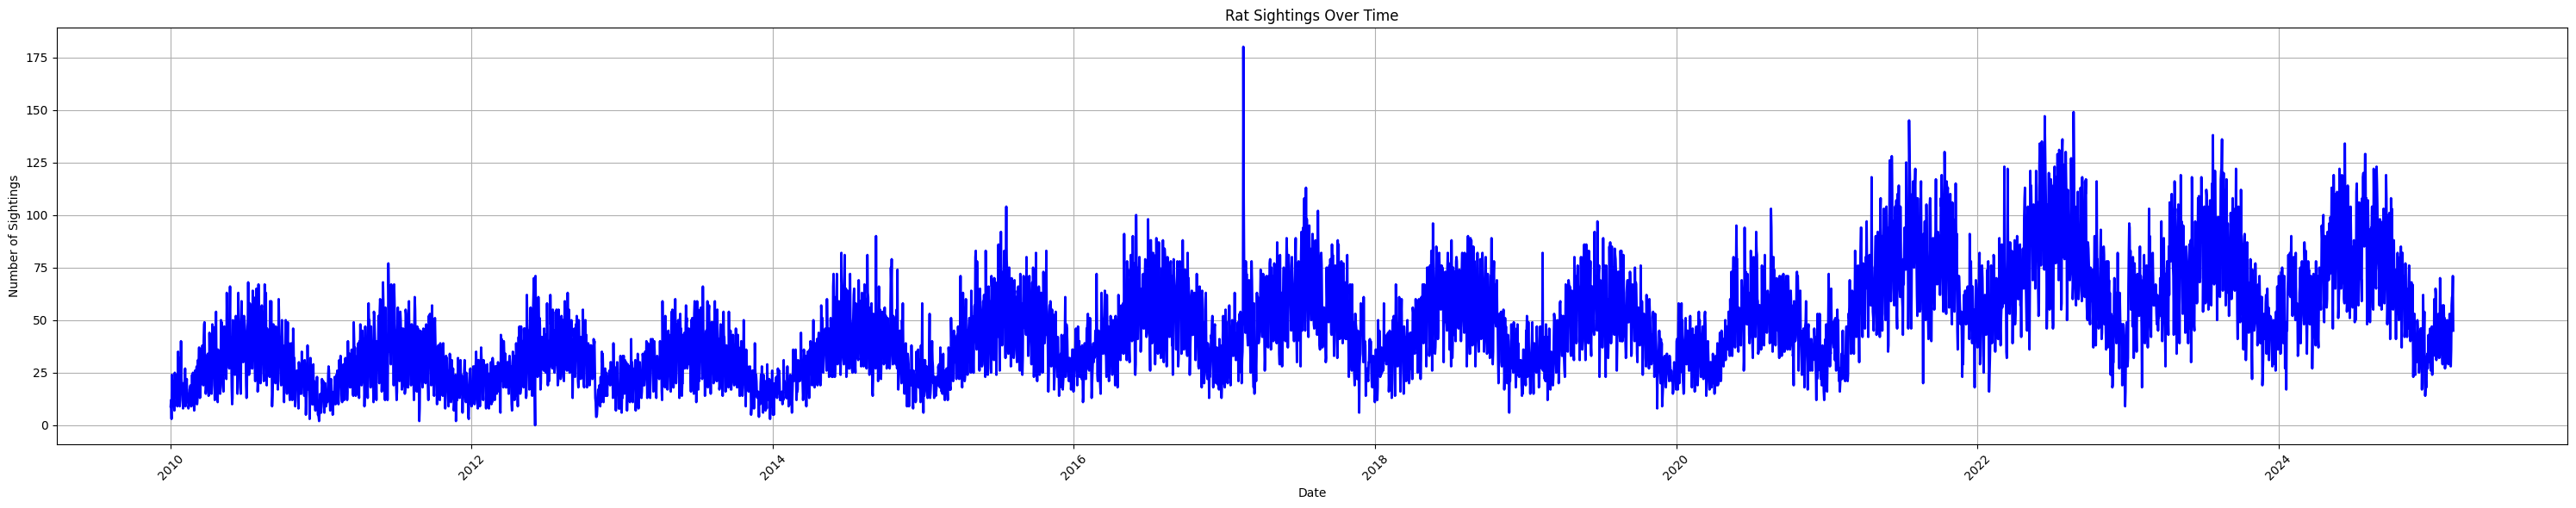

In [4]:
# Plotting the data
plt.figure(figsize=(30, 6)) 
plt.plot(rs_full['ds'], rs_full['y'], label='Rat Sightings', color='b', linewidth=2)

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Number of Sightings')
plt.title('Rat Sightings Over Time')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Show a grid for better readability
plt.grid(True)

# Display the plot
plt.tight_layout()  # Adjust layout to avoid label clipping
plt.show()

In [5]:
# There's a pretty massive outlier there.
# Could be due to clerical issues.
rs[rs['y']>150]


,ds,y
4487,2017-02-15,180


# Prophet Forecasting

In [6]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


In [7]:
date_range = pd.date_range(start="2010-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

## Model Evaluation

We perform the exact same model evaluation process as before (see notebook 1models_citywide.ipynb). We wish to check to see if there is a significant improvement in the model's forecasting abilities.

Running this code, we see that we got a mean RMSE of 13.287273 over the 26 folds. The model got "worse".


In [8]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
prophet_results_df

11:39:08 - cmdstanpy - INFO - Chain [1] start processing
11:39:09 - cmdstanpy - INFO - Chain [1] done processing
11:39:11 - cmdstanpy - INFO - Chain [1] start processing
11:39:12 - cmdstanpy - INFO - Chain [1] done processing
11:39:13 - cmdstanpy - INFO - Chain [1] start processing
11:39:14 - cmdstanpy - INFO - Chain [1] done processing
11:39:16 - cmdstanpy - INFO - Chain [1] start processing
11:39:17 - cmdstanpy - INFO - Chain [1] done processing
11:39:18 - cmdstanpy - INFO - Chain [1] start processing
11:39:19 - cmdstanpy - INFO - Chain [1] done processing
11:39:21 - cmdstanpy - INFO - Chain [1] start processing
11:39:22 - cmdstanpy - INFO - Chain [1] done processing
11:39:23 - cmdstanpy - INFO - Chain [1] start processing
11:39:24 - cmdstanpy - INFO - Chain [1] done processing
11:39:26 - cmdstanpy - INFO - Chain [1] start processing
11:39:27 - cmdstanpy - INFO - Chain [1] done processing
11:39:28 - cmdstanpy - INFO - Chain [1] start processing
11:39:29 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,10.373190,0.137045
1,1,15.405149,0.272875
2,2,13.957667,0.235999
3,3,13.303323,0.135123
4,4,12.367845,0.112321
5,5,19.259569,0.179295
6,6,15.622309,0.126221
7,7,14.881149,0.126164
8,8,11.991555,0.160703
9,9,12.143958,0.121709


# Neural Prophet Forecasting

In [9]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [10]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2010-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

def add_weather_data_no_index(df,wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])

    for column in wd.columns:
        df[column] = wd[column].values

    return df

In [11]:
regressed_features = ['apparent_temperature_max', 
                      'apparent_temperature_min',
                    'snowfall_sum']
wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

In [12]:
lags_for_regressed_features = dict()
lags_for_regressed_features['apparent_temperature_max'] = 30
lags_for_regressed_features['apparent_temperature_min'] = 14
lags_for_regressed_features['snowfall_sum'] = 3

In [13]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()

    train = train.dropna(subset=["y"])


    model = NeuralProphet(yearly_seasonality=True, 
                          weekly_seasonality=True, 
                          epochs = 100,
                          accelerator = 'auto')

    model = model.add_country_holidays(country_name="US")

    for column in regressed_features:
        model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])

    # merge regressors correctly
    # train = train.merge(wd[['ds'] + regressed_features], on="ds", how="left")

    model.fit(train, freq="D", progress="off")

    # build dataframe containing future regressors
    future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_true = test["y"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse, "mape": mape})

neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]
neural_prophet_results_df

Finding best initial lr:   0%|          | 0/243 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 81it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/243 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

...

Predicting: 86it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/243 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 86it [00:00, ?it/s]

,fold,rmse,mape
0,0,14.230194,0.210057
1,1,21.220905,0.393913
2,2,19.852300,0.364664
3,3,11.636740,0.135481
4,4,9.837843,0.093485
5,5,14.556167,0.148121
6,6,15.668619,0.177874
7,7,16.349706,0.180722
8,8,19.325717,0.272765
9,9,13.991843,0.168639
